## **Final Project - Pembelajaran Mesin**

Anggota Kelompok 8 :
- Siti Aisyah Febriyanti (24031554158)
- Arimbi Deby Setyoningrum (24031554186)
- Mutiara Nur Fadhilatun Ni'mah (24031554116)




---

### Judul Project :
## **Klasifikasi Penyakit Daun Jagung Menggunakan Convolutional Neural Network dan Ensemble Classifier untuk Mendukung Ketahanan Pangan**



---

In [1]:
# Uninstall conflicting packages first for a clean environment
!pip uninstall -q -y numpy pandas seaborn matplotlib scikit-learn torchcam Pillow torch torchvision

# ML & Deep Learning (install torch/torchvision first, with CUDA 11.8 support)
# Using common stable versions that are compatible with Colab's Python environment
!pip install -q torch==2.3.0 --index-url https://download.pytorch.org/whl/cu118 --no-cache-dir
!pip install -q torchvision==0.18.0 --index-url https://download.pytorch.org/whl/cu118 --no-cache-dir

# Core numerical & data (install compatible, recent versions)
!pip install -q "numpy==2.0.0"      --no-cache-dir
!pip install -q "pandas==2.2.2"      --no-cache-dir
!pip install -q "matplotlib==3.9.0"  --no-cache-dir # Updated to resolve conflict with pointpats
!pip install -q "seaborn==0.13.2"    --no-cache-dir
!pip install -q "Pillow==9.5.0"      --no-cache-dir # Downgraded for torchvision compatibility

# Other ML & Utilities
!pip install -q "scikit-learn==1.6.0" --no-cache-dir # Updated to resolve conflict with umap-learn, cuml-cu12, hdbscan
!pip install -q "tqdm==4.67.0"      --no-cache-dir
!pip install -q "ipywidgets==8.1.2" --no-cache-dir

# Grad-CAM (using torchcam, as 'grad-cam==1.5.0' was not found)
!pip install -q "torchcam==0.4.0" --no-cache-dir

print("Done! Restart runtime now.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.6/839.6 MB 258.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 311.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 426.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 243.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.5/728.5 MB 293.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 310.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 185.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 276.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 281.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 333.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.9/142.9 MB 240.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 264.4 MB/s eta 0:00:00
ERROR: pip's dependency reso

In [2]:
!pip install --upgrade numpy pandas seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 76.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchcam 0.4.0 requires numpy<2.0.0,>=1.17.2, but you have numpy 2.4.6 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
cudf-cu1

# Import Session

In [3]:
# Core imports
import os, tarfile, urllib.request, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, random_split
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder

# Sklearn
from sklearn.metrics import confusion_matrix, classification_report

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')
print(f'Torchvision version: {torchvision.__version__}')

Using device: cuda
PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128


In [4]:
import os
import cv2
import shutil
import random
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
import pandas as pd
from collections import defaultdict

sns.set_style("whitegrid")

In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Seed locked: {SEED}")

Seed locked: 42


# Preparing Dataset

In [6]:
import zipfile, shutil

DATA_ROOT = Path('./data/corn_maize_leaf')

def download_corn_maize_kaggle(root: Path):
    root.mkdir(parents=True, exist_ok=True)
    marker = root / '.done_raw'

    if marker.exists():
        print('Raw dataset already prepared.')
        return

    try:
        print('Downloading Corn or Maize Leaf Disease Dataset from Kaggle...')

        # download dataset
        os.system(
            'kaggle datasets download -d smaranjitghose/corn-or-maize-leaf-disease-dataset'
        )

        zip_path = Path('corn-or-maize-leaf-disease-dataset.zip')

        print('Extracting dataset...')
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(root / '_raw')

        raw_path = root / '_raw'

        image_paths = []
        labels = []

        # cari semua gambar dan label
        for class_dir in raw_path.rglob('*'):
            if class_dir.is_dir():

                for img_path in class_dir.glob('*.*'):
                    if img_path.suffix.lower() in [
                        '.png', '.jpg', '.jpeg'
                    ]:
                        image_paths.append(img_path)
                        labels.append(class_dir.name.lower())

        # ambil semua class unik
        target_classes = sorted(set(labels))

        print(f"Detected classes: {target_classes}")

        # filter data valid
        data = [
            (p, l)
            for p, l in zip(image_paths, labels)
            if l in target_classes
        ]

        # buat folder raw
        raw_clean = root / 'raw'

        for cls in target_classes:
            (raw_clean / cls).mkdir(parents=True, exist_ok=True)

        # copy dan rename file
        for i, (src, label) in enumerate(
            tqdm(data, desc='Organizing RAW')
        ):
            dst = raw_clean / label / f'{i:05d}{src.suffix}'
            shutil.copy(src, dst)

        marker.touch()

        print(f'\nRAW dataset ready!')
        print(f'Total classes: {len(target_classes)}')

    except Exception as e:
        print(f'Error: {e}')
        print('Pastikan Kaggle API sudah dikonfigurasi!')


# RUN
download_corn_maize_kaggle(DATA_ROOT)

# VERIFY
data_dir = DATA_ROOT / 'raw'

classes = sorted([
    d.name for d in data_dir.iterdir()
    if d.is_dir()
])

print(f"\nClasses ({len(classes)}): {classes}")

n_total = sum(
    len(list((data_dir / c).glob('*.*')))
    for c in classes
)

print(f"Total images: {n_total}")

Extracting dataset...
Detected classes: ['blight', 'common_rust', 'gray_leaf_spot', 'healthy']


Organizing RAW:   0%|          | 0/4188 [00:00<?, ?it/s]


RAW dataset ready!
Total classes: 4

Classes (4): ['blight', 'common_rust', 'gray_leaf_spot', 'healthy']
Total images: 4188


# Aspek Data

In [7]:
records = []

for label in os.listdir(data_dir):
    label_path = os.path.join(data_dir, label)

    if os.path.isdir(label_path):

        for img_name in os.listdir(label_path):
            img_path = os.path.join(label_path, img_name)

            try:
                img = Image.open(img_path)
                arr = np.array(img)

                width, height = img.size
                channels = arr.shape[2] if len(arr.shape) == 3 else 1
                img_size = os.path.getsize(img_path) / 1024  # KB

                records.append({
                    "filename": img_name,
                    "label": label,
                    "width": width,
                    "height": height,
                    "channels": channels,
                    "file_size_kb": img_size
                })

            except:
                records.append({
                    "filename": img_name,
                    "label": label,
                    "width": np.nan,
                    "height": np.nan,
                    "channels": np.nan,
                    "file_size_kb": np.nan
                })

df = pd.DataFrame(records)

print(df.head())
print(df.shape)

    filename    label  width  height  channels  file_size_kb
0  03536.jpg  healthy    256     256         3     16.250000
1  03338.jpg  healthy    256     256         3      8.937500
2  03532.jpg  healthy    256     256         3      8.375000
3  03471.jpg  healthy    256     256         3     16.415039
4  03568.jpg  healthy    256     256         3     12.942383
(4188, 6)


In [8]:
df.describe()

,width,height,channels,file_size_kb
count,4188.000000,4188.000000,4188.000000,4188.000000
mean,307.536533,297.906160,3.001194,39.915494
std,285.716933,253.138674,0.034536,227.460337
min,180.000000,116.000000,3.000000,3.783203
25%,256.000000,256.000000,3.000000,11.618164
50%,256.000000,256.000000,3.000000,13.691895
75%,256.000000,256.000000,3.000000,15.799805
max,5184.000000,5184.000000,4.000000,6419.989258


In [9]:
attribute_desc = pd.DataFrame({
    "Attribute": df.columns,
    "Description": [
        "Nama file gambar",
        "Kategori penyakit jagung",
        "Lebar gambar (pixel)",
        "Tinggi gambar (pixel)",
        "Jumlah channel warna",
        "Ukuran file gambar (KB)"
    ],
    "Data Type": df.dtypes.values
})

attribute_desc

,Attribute,Description,Data Type
0,filename,Nama file gambar,object
1,label,Kategori penyakit jagung,object
2,width,Lebar gambar (pixel),int64
3,height,Tinggi gambar (pixel),int64
4,channels,Jumlah channel warna,int64
5,file_size_kb,Ukuran file gambar (KB),float64


label
common_rust       1306
healthy           1162
blight            1146
gray_leaf_spot     574
Name: count, dtype: int64


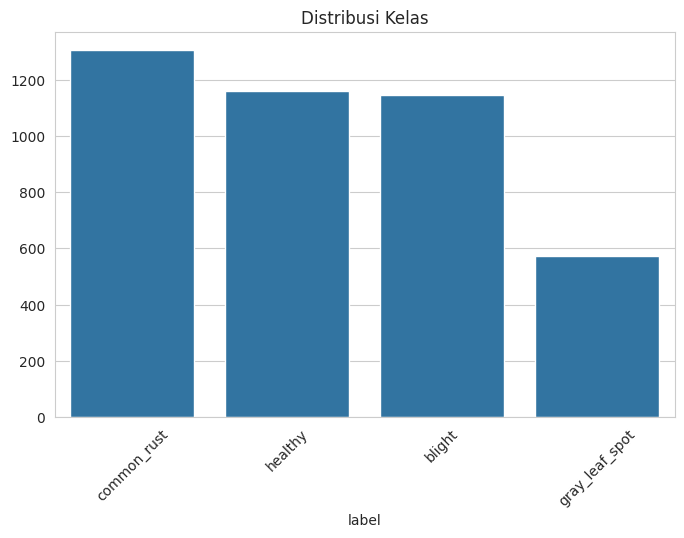

In [10]:
#cek pesebaran data
class_counts = df["label"].value_counts()

print(class_counts)

plt.figure(figsize=(8,5))
sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.xticks(rotation=45)
plt.title("Distribusi Kelas")
plt.show()

In [11]:
imbalance_ratio = class_counts.max() / class_counts.min()

print("Imbalance Ratio:", imbalance_ratio)

Imbalance Ratio: 2.275261324041812


In [12]:
min_class = class_counts.min()

ratio = (class_counts / min_class).round(2)

print(ratio)

label
common_rust       2.28
healthy           2.02
blight            2.00
gray_leaf_spot    1.00
Name: count, dtype: float64


In [13]:
#sparsity
def calc_sparsity(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    total_pixels = img.size
    zero_pixels = np.sum(img == 0)

    return (zero_pixels / total_pixels) * 100

In [14]:
sample_paths = []

for label in os.listdir(data_dir):
    folder = os.path.join(data_dir, label)

    imgs = os.listdir(folder)[:100]

    for img in imgs:
        sample_paths.append(os.path.join(folder, img))

sparsity_scores = [calc_sparsity(p) for p in sample_paths]

print("Average Sparsity:", np.mean(sparsity_scores), "%")

Average Sparsity: 4.847429180227302 %


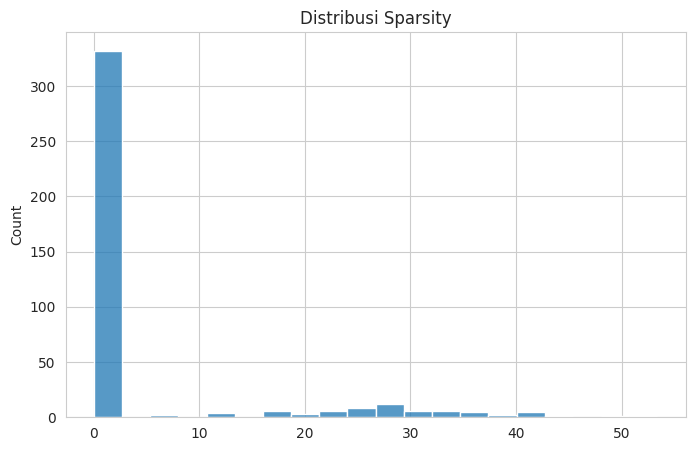

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(sparsity_scores, bins=20)
plt.title("Distribusi Sparsity")
plt.show()

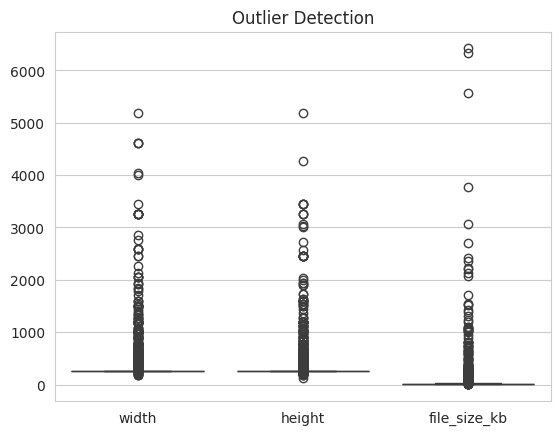

In [16]:
sns.boxplot(data=df[["width", "height", "file_size_kb"]])
plt.title("Outlier Detection")
plt.show()

In [17]:
def outlier_count(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    return len(outliers)

for col in ["width", "height", "file_size_kb"]:
    print(col, ":", outlier_count(col))

width : 335
height : 336
file_size_kb : 332


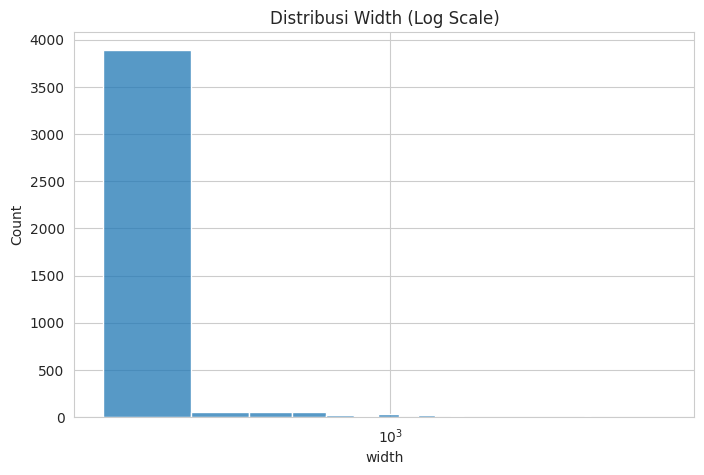

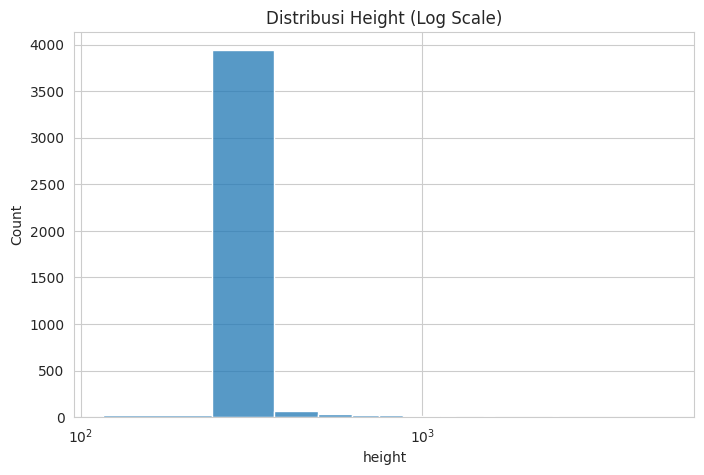

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df["width"], bins=40)

plt.xscale("log")
plt.title("Distribusi Width (Log Scale)")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["height"], bins=40)

plt.xscale("log")
plt.title("Distribusi Height (Log Scale)")
plt.show()

In [19]:
def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = []

for label in os.listdir(data_dir):
    folder = os.path.join(data_dir, label)

    for img_name in os.listdir(folder):
        path = os.path.join(folder, img_name)
        hashes.append(file_hash(path))

duplicates = len(hashes) - len(set(hashes))

print("Duplicate images:", duplicates)

Duplicate images: 2


In [20]:

corrupt_images = []

for label in os.listdir(data_dir):
    folder = os.path.join(data_dir, label)

    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)

        try:
            img = Image.open(img_path)
            img.verify()   # cek file valid
        except:
            corrupt_images.append(img_path)

print("Jumlah corrupt/missing images:", len(corrupt_images))

Jumlah corrupt/missing images: 0


# Data Eksploration

In [21]:
class_dropdown = widgets.Dropdown(
    options=classes,
    description='Class:',
    style={'description_width': 'initial'}
)

n_images_slider = widgets.IntSlider(
    value=6, min=2, max=16, step=2,
    description='# Images:',
    style={'description_width': 'initial'}
)

def show_class_samples(class_name, n_images):
    cls_dir = data_dir / class_name

    imgs = [p for p in cls_dir.rglob('*')
            if p.suffix.lower() in ['.png','.jpg','.jpeg', 'Other']][:n_images]

    if len(imgs) == 0:
        print("No images found!")
        return

    fig, axes = plt.subplots(1, len(imgs), figsize=(3 * len(imgs), 3))

    if len(imgs) == 1:
        axes = [axes]

    fig.suptitle(f'Class: {class_name} (RAW DATA)', fontsize=14, weight='bold')

    for ax, img_path in zip(axes, imgs):
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f'{img.size[0]}×{img.size[1]}', fontsize=8)

    plt.tight_layout()
    plt.show()

out = widgets.interactive_output(
    show_class_samples,
    {'class_name': class_dropdown, 'n_images': n_images_slider}
)

display(widgets.HBox([class_dropdown, n_images_slider]), out)

Output()

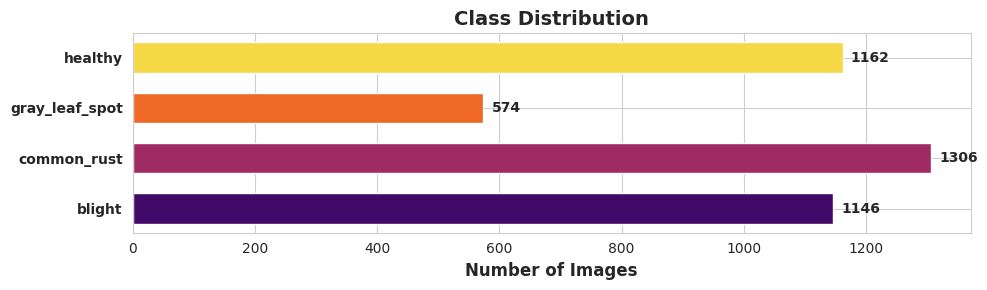

In [22]:
counts = {
    cls: len(list((data_dir / cls).glob('*.*')))
    for cls in classes
}

labels = list(counts.keys())
values = list(counts.values())

# warna bar chart
colors = plt.cm.inferno(np.linspace(0.2, 0.9, len(labels)))

y_pos = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(10, 3))

bars = ax.barh(y_pos, values, color=colors, height=0.6)

# Set label posisi Y
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontweight='bold')

# Judul & label
ax.set_xlabel('Number of Images', fontsize=12, fontweight='bold')
ax.set_title('Class Distribution', fontsize=14, fontweight='bold')

# Angka di samping bar
for i, v in enumerate(values):
    ax.text(
        v + max(values)*0.01,
        i,
        str(v),
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [23]:
def analyze_image_quality_raw(data_dir, classes, sample_per_class=50):
    results = {}

    for cls in classes:
        cls_dir = data_dir / cls

        # ambil semua citra
        img_paths = [
            p for p in cls_dir.rglob('*')
            if p.suffix.lower() in ['.png', '.jpg', '.jpeg', 'Other']
        ][:sample_per_class]

        brightness = []
        contrast = []
        sizes = []

        for img_path in img_paths:
            try:
                img = Image.open(img_path).convert('L')
                img_np = np.array(img)

                brightness.append(np.mean(img_np))
                contrast.append(np.std(img_np))
                sizes.append(img.size)

            except:
                continue

        # hitung statistik
        results[cls] = {
            'brightness_mean': np.mean(brightness) if brightness else 0,
            'brightness_std': np.std(brightness) if brightness else 0,

            'contrast_mean': np.mean(contrast) if contrast else 0,
            'contrast_std': np.std(contrast) if contrast else 0,

            'avg_size': np.mean(sizes, axis=0) if sizes else (0, 0)
        }

    return results


# RUN
quality_results = analyze_image_quality_raw(data_dir, classes)

# PRINT HASIL
for cls, vals in quality_results.items():
    print(f"\nClass: {cls}")
    print(f"Brightness  : {vals['brightness_mean']:.2f} ± {vals['brightness_std']:.2f}")
    print(f"Contrast    : {vals['contrast_mean']:.2f} ± {vals['contrast_std']:.2f}")
    print(f"Avg Size    : {vals['avg_size']}")


Class: blight
Brightness  : 116.44 ± 8.05
Contrast    : 31.98 ± 7.45
Avg Size    : [288.62 281.58]

Class: common_rust
Brightness  : 94.01 ± 14.58
Contrast    : 61.47 ± 8.76
Avg Size    : [289.94 277.26]

Class: gray_leaf_spot
Brightness  : 118.83 ± 8.45
Contrast    : 38.45 ± 11.04
Avg Size    : [280.12 275.84]

Class: healthy
Brightness  : 143.87 ± 22.52
Contrast    : 33.69 ± 8.44
Avg Size    : [256. 256.]


# Resize

In [24]:
raw_dir = DATA_ROOT / 'raw'
resize_dir = DATA_ROOT / 'preprocessed'

if resize_dir.exists():
    shutil.rmtree(resize_dir)

resize_dir.mkdir(parents=True, exist_ok=True)

In [25]:
print(raw_dir.exists())
print(resize_dir.exists())
print(os.listdir(raw_dir))

True
True
['healthy', 'blight', 'common_rust', 'gray_leaf_spot']


In [26]:
target_size = (224, 224)

for label in os.listdir(raw_dir):
  src_folder = raw_dir / label
  if not src_folder.is_dir():
    continue

  dst_folder = resize_dir / label
  os.makedirs(dst_folder, exist_ok= True)

  for img_name in os.listdir(src_folder):
    img_path = src_folder / img_name
    save_path = dst_folder /img_name


    try:
      img = Image.open(img_path).convert("RGB")
      img = img.resize(target_size)
      img.save(save_path)

    except Exception as e:
      print("error:", img_path, e)

print("resize done")


resize done


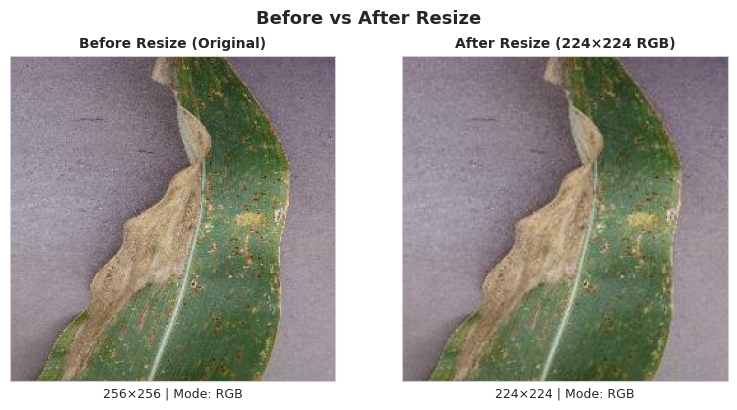

In [27]:
raw_dir = DATA_ROOT / 'raw'
resize_dir = DATA_ROOT / 'preprocessed'

label = 'blight'

raw_cls_dir = raw_dir / label
raw_img_path = list(raw_cls_dir.glob('*.*'))[0]
raw_img = Image.open(raw_img_path)

resize_img = Image.open(resize_dir / label / raw_img_path.name).convert("RGB")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
fig.suptitle('Before vs After Resize', fontsize=13, fontweight='bold')

# before
axes[0].imshow(raw_img.convert("RGB"))
axes[0].set_title('Before Resize (Original)', fontsize=10, fontweight='bold')
axes[0].set_xlabel(f'{raw_img.size[0]}×{raw_img.size[1]} | Mode: {raw_img.mode}', fontsize=9)
axes[0].set_xticks([])
axes[0].set_yticks([])

# after
axes[1].imshow(resize_img)
axes[1].set_title('After Resize (224×224 RGB)', fontsize=10, fontweight='bold')
axes[1].set_xlabel(f'{resize_img.size[0]}×{resize_img.size[1]} | Mode: {resize_img.mode}', fontsize=9)
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.tight_layout()
plt.savefig('before_after_blight.png', dpi=150, bbox_inches='tight')
plt.show()

# SPLIT DATA

In [28]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [29]:
dataset = ImageFolder(
    root = resize_dir,
    transform=transform
)

In [30]:
total_size = len(dataset)
train_size = int(0.8 * total_size)
val_size = int(0.10 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train: {len(train_dataset)}")
print(f"Validation: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")

Train: 3350
Validation: 418
Test: 420


# Preprocessing

## under sampling

In [31]:
label_indices = defaultdict(list)

In [32]:
for idx in train_dataset.indices:
  _, label = dataset.samples[idx]
  label_indices[label].append(idx)

for label, indices in label_indices.items():
    print(f"{dataset.classes[label]}: {len(indices)}")

common_rust: 1044
healthy: 937
gray_leaf_spot: 458
blight: 911


In [33]:
min_count = min(len(indices) for indices in label_indices.values())

In [34]:
print(min_count)

458


In [35]:
random.seed(42)
balanced_indices = []

for label, indices in label_indices.items():
    random.seed(42)
    sampled = random.sample(indices, min_count)
    balanced_indices.extend(sampled)

random.shuffle(balanced_indices)

train_dataset = Subset(dataset, balanced_indices)

In [36]:
# cek hasil setelah undersampling
after_sampling = defaultdict(int)

for idx in balanced_indices:
    _, label = dataset.samples[idx]
    after_sampling[label] += 1

print("\nDistribusi kelas setelah undersampling:")
for label, count in after_sampling.items():
    print(f"{dataset.classes[label]}: {count}")


Distribusi kelas setelah undersampling:
gray_leaf_spot: 458
blight: 458
healthy: 458
common_rust: 458


## CLAHE

In [37]:
def apply_clahe(img) :
  img= np.array(img)
  lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
  l, a, b = cv2.split(lab)

  clahe= cv2.createCLAHE(
      clipLimit =2.0,
      tileGridSize= (8,8)
  )
  l = clahe.apply(l)

  merged = cv2.merge((l, a, b))
  img = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)
  return Image.fromarray(img)

## Gaussian Blur

In [38]:
def apply_gaussian(img):
    img = np.array(img)
    img = cv2.GaussianBlur(img, (5,5), 0)
    return Image.fromarray(img)

## ToTensor

In [39]:
transform = transforms.Compose([
    transforms.Lambda(apply_clahe),
    transforms.Lambda(apply_gaussian),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset.transform = transform

In [40]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [41]:
class_names = dataset.classes

def show_sample(target_class, sample_num):

    class_idx = class_names.index(target_class)

    class_samples = []

    for idx in train_dataset.indices:
        _, label = dataset.samples[idx]
        if label == class_idx:
            class_samples.append(idx)

    if len(class_samples) == 0:
        print("Sample tidak ditemukan")
        return

    sample_num = min(sample_num, len(class_samples))
    selected_idx = class_samples[sample_num - 1]

    original_path = dataset.samples[selected_idx][0]
    original = Image.open(original_path).convert("RGB")

    clahe = apply_clahe(original)
    gaussian = apply_gaussian(clahe)

    img = dataset[selected_idx][0]

    normalized_img = img.permute(1, 2, 0).numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])


    denormalized_img = (normalized_img * std) + mean
    denormalized_img = np.clip(denormalized_img, 0, 1)

    plt.figure(figsize=(20, 4))

    images = [
        original,
        clahe,
        gaussian,
        normalized_img,
        denormalized_img
    ]

    titles = [
        "Original",
        "CLAHE",
        "Gaussian Blur",
        "After Normalize",
        "Denormalized"
    ]


    for i in range(len(images)):

        plt.subplot(1, 5, i + 1)

        if titles[i] == "After Normalize":
            display_img = (
                normalized_img - normalized_img.min()
            ) / (
                normalized_img.max() - normalized_img.min()
            )

            plt.imshow(display_img)

        else:
            plt.imshow(images[i])

        plt.title(titles[i])
        plt.axis("off")

    plt.suptitle(
        f"Class: {target_class} | Sample {sample_num}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

In [42]:
display(
    widgets.interactive(
        show_sample,
        target_class=widgets.Dropdown(
            options=class_names,
            description='Class:'
        ),
        sample_num=widgets.IntSlider(
            min=1,
            max=20,
            step=1,
            value=1,
            description='Sample:'
        )
    )
)

interactive(children=(Dropdown(description='Class:', options=('blight', 'common_rust', 'gray_leaf_spot', 'heal…

# Features Extraction

In [43]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

feature_extractor = mobilenet.features

feature_extractor = feature_extractor.to(DEVICE)

for param in feature_extractor.parameters():
    param.requires_grad = False

feature_extractor.eval()

print(feature_extractor)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 209MB/s]


Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU6(inplace=True)
  )
  (1): InvertedResidual(
    (conv): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (2): InvertedResidual(
    (conv): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (

In [44]:
def extract_features(dataloader, model):
    features = []
    labels = []

    with torch.no_grad():
        for imgs, lbls in dataloader:
            imgs = imgs.to(DEVICE)

            feats = model(imgs)

            # flatten output
            feats = torch.nn.functional.adaptive_avg_pool2d(feats, 1).flatten(1)

            features.append(feats.cpu())
            labels.append(lbls)

    features = torch.cat(features)
    labels = torch.cat(labels)

    return features, labels

In [45]:
train_features, train_labels = extract_features(
    train_loader,
    feature_extractor
)

val_features, val_labels = extract_features(
    val_loader,
    feature_extractor
)

test_features, test_labels = extract_features(
    test_loader,
    feature_extractor
)

print("Train features:", train_features.shape)
print("Validation features:", val_features.shape)
print("Test features:", test_features.shape)

Train features: torch.Size([1832, 1280])
Validation features: torch.Size([418, 1280])
Test features: torch.Size([420, 1280])


In [46]:
#visualisasi
img, label = train_dataset[0]

input_img = img.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    feature_maps = feature_extractor(input_img)

feature_maps = feature_maps.cpu().squeeze(0)

print(feature_maps.shape)

torch.Size([1280, 7, 7])


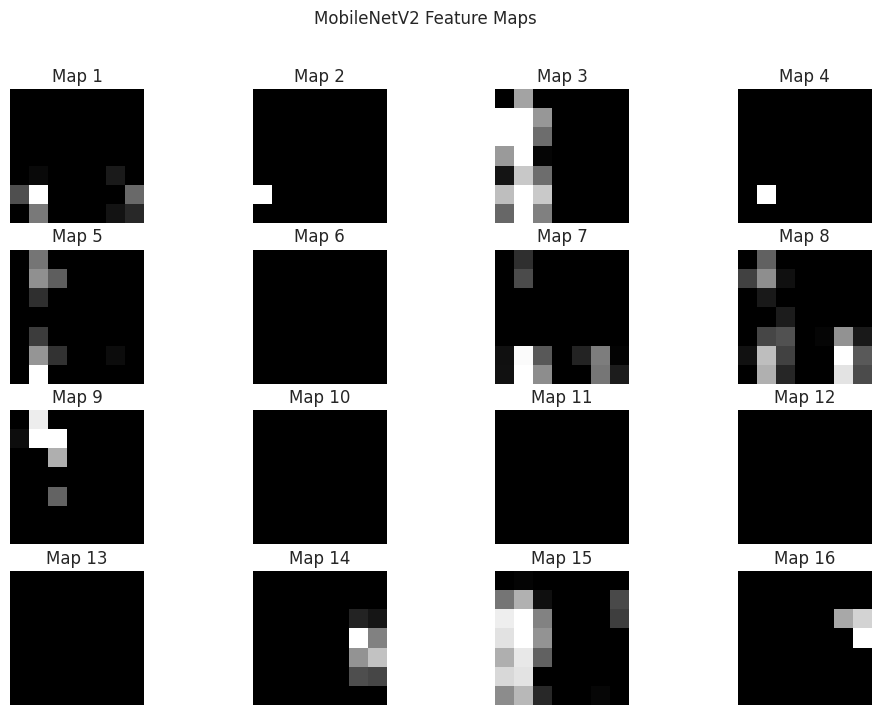

In [47]:
plt.figure(figsize=(12,8))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(feature_maps[i], cmap='gray')
    plt.title(f"Map {i+1}")
    plt.axis("off")

plt.suptitle("MobileNetV2 Feature Maps")
plt.show()

In [48]:
!pip install xgboost
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [49]:
X_train = train_features.numpy()
y_train = train_labels.numpy()

X_val = val_features.numpy()
y_val = val_labels.numpy()

X_test = test_features.numpy()
y_test = test_labels.numpy()

print(X_train.shape)
print(y_train.shape)

(1832, 1280)
(1832,)


# Random Forest Classifier

In [50]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [51]:
class_names = dataset.classes

print("Random Forest Classification Report")
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=class_names
    )
)

Random Forest Classification Report
                precision    recall  f1-score   support

        blight       0.88      0.80      0.83       123
   common_rust       1.00      0.95      0.98       129
gray_leaf_spot       0.64      0.82      0.72        55
       healthy       0.98      1.00      0.99       113

      accuracy                           0.90       420
     macro avg       0.88      0.89      0.88       420
  weighted avg       0.91      0.90      0.91       420



In [52]:
train_score = rf_model.score(X_train, y_train)
test_score = rf_model.score(X_test, y_test)

print("Train Accuracy:", train_score)
print("Test Accuracy:", test_score)

Train Accuracy: 0.9994541484716157
Test Accuracy: 0.9023809523809524


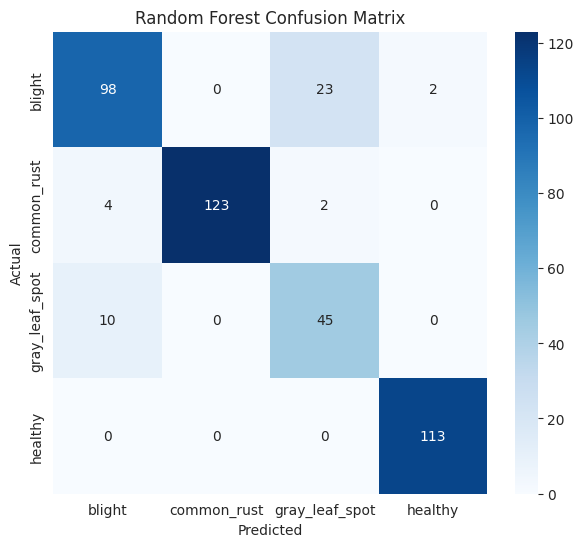

In [53]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Visualisasi** **Tree** **Representatif**

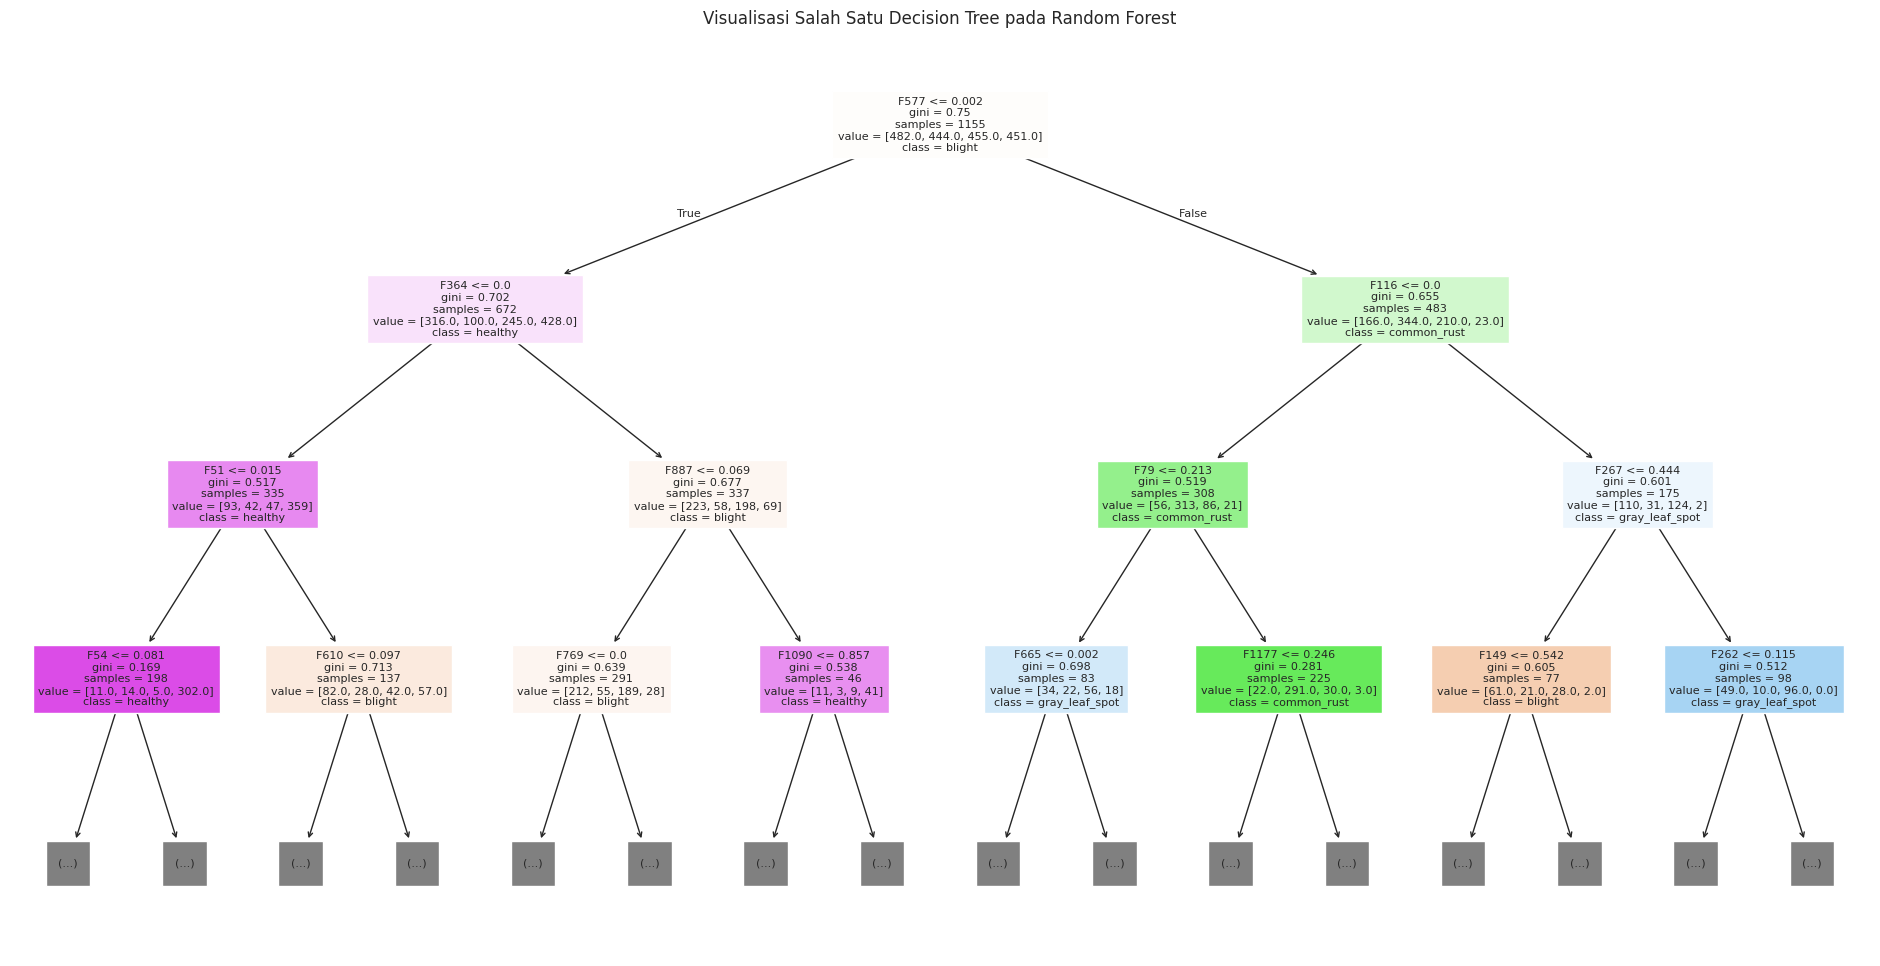

In [54]:
from sklearn.tree import plot_tree

plt.figure(figsize=(24,12))

plot_tree(
    rf_model.estimators_[0],   # tree pertama
    feature_names=[f"F{i}" for i in range(train_features.shape[1])],
    class_names=dataset.classes,
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.title("Visualisasi Salah Satu Decision Tree pada Random Forest")
plt.show()

**Visualisasi** **Feature** **Importance**


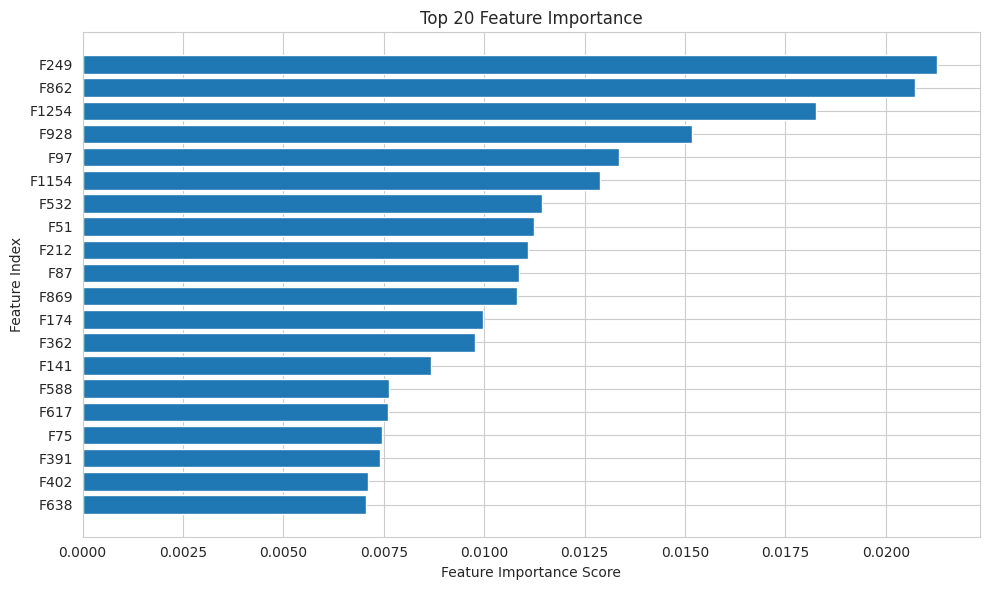

In [55]:
importance = rf_model.feature_importances_

top_idx = importance.argsort()[-20:]

plt.figure(figsize=(10,6))
plt.barh(range(20), importance[top_idx])
plt.yticks(range(20), [f"F{i}" for i in top_idx])
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature Index")
plt.title("Top 20 Feature Importance")
plt.tight_layout()
plt.show()

# XGBoost Classifier

In [56]:
xgb_model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=5,
    objective='multi:softmax',
    num_class=4,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_test)

In [57]:
print("XGBoost Classification Report")

print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=class_names
    )
)

XGBoost Classification Report
                precision    recall  f1-score   support

        blight       0.86      0.85      0.85       123
   common_rust       0.99      0.95      0.97       129
gray_leaf_spot       0.69      0.78      0.74        55
       healthy       0.99      0.99      0.99       113

      accuracy                           0.91       420
     macro avg       0.88      0.89      0.89       420
  weighted avg       0.91      0.91      0.91       420



In [58]:
train_score = xgb_model.score(X_train, y_train)
test_score = xgb_model.score(X_test, y_test)

print("Train Accuracy:", train_score)
print("Test Accuracy:", test_score)

Train Accuracy: 0.9994541484716157
Test Accuracy: 0.9095238095238095


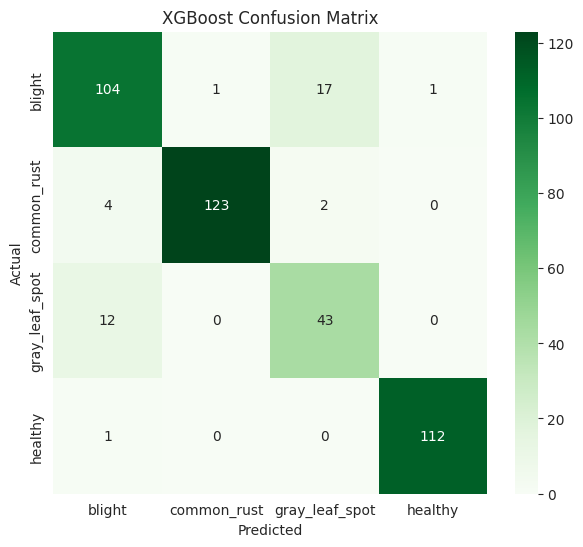

In [59]:
cm_xgb = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

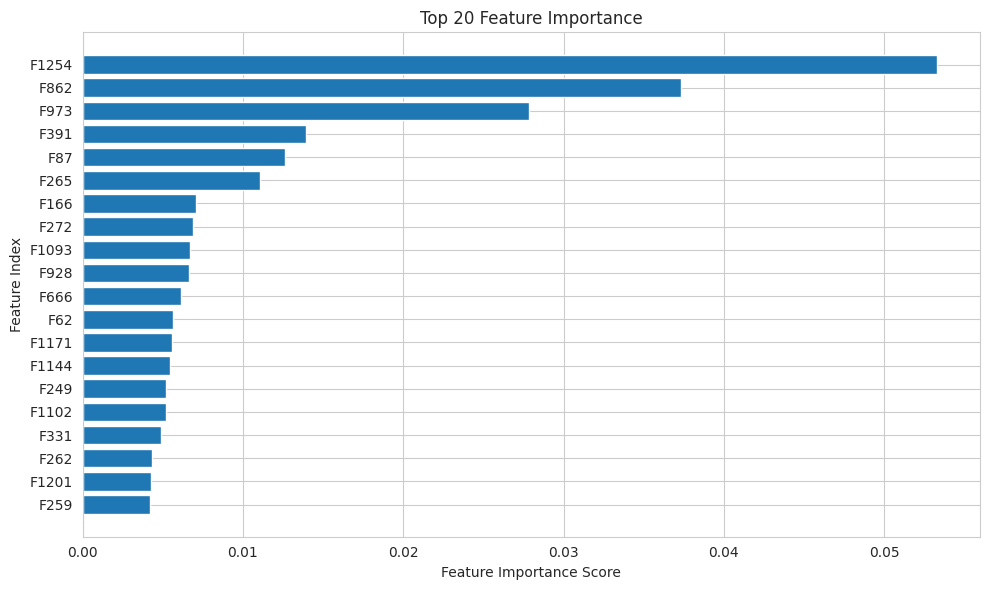

In [60]:
importance = xgb_model.feature_importances_

top_idx = importance.argsort()[-20:]

plt.figure(figsize=(10,6))
plt.barh(range(20), importance[top_idx])
plt.yticks(range(20), [f"F{i}" for i in top_idx])
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature Index")
plt.title("Top 20 Feature Importance")
plt.tight_layout()
plt.show()

Visualisasi (training vs validation loss)

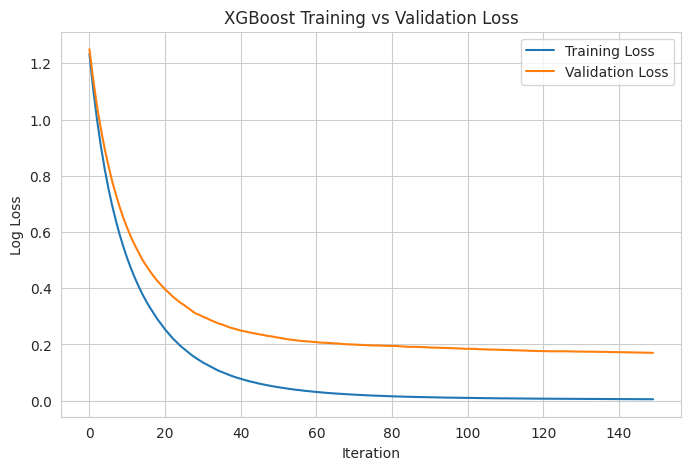

In [61]:
results = xgb_model.evals_result()

train_loss = results['validation_0']['mlogloss']
val_loss = results['validation_1']['mlogloss']
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(
    train_loss,
    label='Training Loss')
plt.plot(
    val_loss,
    label='Validation Loss')
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.title("XGBoost Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

Visualisasi Validasi

In [62]:
val_pred = xgb_model.predict(X_val)

Confusion Matrix Validasi

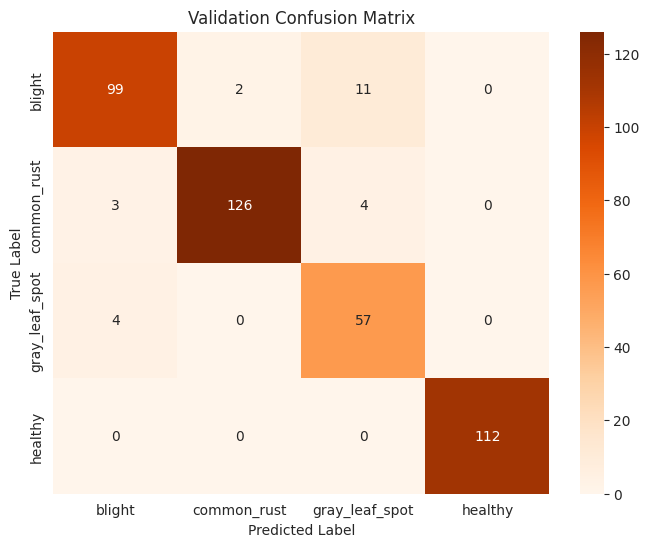

In [63]:
class_names = dataset.classes
cm_val = confusion_matrix(y_val, val_pred)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm_val,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=class_names,
    yticklabels=class_names)

plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Visualisasi Validasi

<Figure size 1000x600 with 0 Axes>

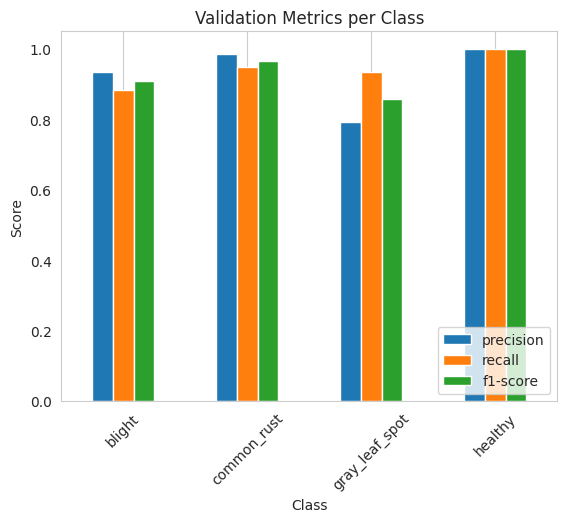

In [64]:
val_pred = xgb_model.predict(X_val)

report = classification_report(
    y_val,
    val_pred,
    target_names=class_names,
    output_dict=True)
report_df = pd.DataFrame(report).transpose()
metrics_df = report_df.iloc[:-3][['precision', 'recall', 'f1-score']]

plt.figure(figsize=(10,6))
metrics_df.plot(kind='bar')
plt.title("Validation Metrics per Class")
plt.ylabel("Score")
plt.xlabel("Class")
plt.ylim(0, 1.05)
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.show()